In [1]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


inspection_id = "0A49KLT3B7Y" #fhr8
angle_profiles = ["0"]
num_tracks = 22
run_number = 8
results_dir = f"./data-files/insp_{inspection_id}_dent_detection_us2_lora"

In [2]:
def download_s3_folder(bucket_name: str, s3_folder: str, local_dir: str = None):
    """
    Download the contents of a folder directory
    Args:
        bucket_name: the name of the s3 bucket
        s3_folder: the folder path in the s3 bucket
        local_dir: the dir data is downloaded to
    """
    s3 = boto3.resource("s3")
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=s3_folder):
        target = (
            obj.key
            if local_dir is None
            else os.path.join(local_dir, os.path.relpath(obj.key, s3_folder))
        )
        if not os.path.exists(os.path.dirname(target)):
            os.makedirs(os.path.dirname(target))
        if obj.key[-1] == "/":
            continue
        if not os.path.exists(target):
            bucket.download_file(obj.key, target)
            print("Downloading: {}".format(obj.key))

if not os.path.exists(results_dir):
    os.makedirs(results_dir)

download_s3_folder("dv-test-prefect", f"track_runs/{inspection_id}/corrosion_detection/", results_dir)

Downloading: track_runs/0A49KLT3B7Y/corrosion_detection/track_00/01-000-11YWD5E5/0/frames_000000000000_000000050000_000001.parquet
Downloading: track_runs/0A49KLT3B7Y/corrosion_detection/track_00/01-000-11YWD5E5/0/frames_000000050000_000000100000_000001.parquet
Downloading: track_runs/0A49KLT3B7Y/corrosion_detection/track_00/01-000-11YWD5E5/0/frames_000000100000_000000150000_000001.parquet
Downloading: track_runs/0A49KLT3B7Y/corrosion_detection/track_00/01-000-11YWD5E5/0/frames_000000150000_000000200000_000001.parquet
Downloading: track_runs/0A49KLT3B7Y/corrosion_detection/track_00/01-000-11YWD5E5/0/frames_000000200000_000000250000_000001.parquet
Downloading: track_runs/0A49KLT3B7Y/corrosion_detection/track_00/01-000-11YWD5E5/0/frames_000000250000_000000300000_000001.parquet
Downloading: track_runs/0A49KLT3B7Y/corrosion_detection/track_00/01-000-11YWD5E5/0/frames_000000300000_000000350000_000001.parquet
Downloading: track_runs/0A49KLT3B7Y/corrosion_detection/track_00/01-000-11YWD5E5/0/

KeyboardInterrupt: 

In [3]:

root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))

In [4]:
len(data_files), data_files

(54,
 [PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_us2_lora/track_12/01-012-11YWDS1R/0/frames_000013150000_000013200000_000001.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_us2_lora/track_12/01-012-11YWDS1R/0/frames_000013200000_000013250000_000001.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_us2_lora/track_12/01-012-11YWDS1R/0/frames_000013250000_000013300000_000001.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_us2_lora/track_12/01-012-11YWDS1R/0/frames_000013300000_000013350000_000001.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_us2_lora/track_12/01-012-11YWDS1R/0/frames_000013350000_000013400000_000001.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_us2_lora/track_12/01-012-11YWDS1R/0/frames_000013400000_000013450000_000001.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_us2_lora/track_12/01-012-11YWDS1R/0/frames_000013450000_000013500000_000001.parqu

In [5]:
data_files[-2]
df = pd.read_parquet(data_files[-2])
#remove attn_map columns
df = df.drop(columns=[col for col in df.columns if "attn_map" in col])
df.head()
#13488222

,inspection_id,clip_id,track_id,frame_idx,timer_tick,odometer_tick,lam_prob
0,0A49KLT3B7Y,01-021-11YWDR6A,21,14400000,418598117,218679901,0.410684
1,0A49KLT3B7Y,01-021-11YWDR6A,21,14400001,418598140,218679916,0.410684
2,0A49KLT3B7Y,01-021-11YWDR6A,21,14400002,418598165,218679931,0.410684
3,0A49KLT3B7Y,01-021-11YWDR6A,21,14400003,418598186,218679946,0.410684
4,0A49KLT3B7Y,01-021-11YWDR6A,21,14400004,418598210,218679961,0.410684


In [6]:
def keep_confident(df, threshold=0.5, score_col='lam_prob'):
    """
    Keep only rows where crack_score is greater than the given threshold.
    """
    return df[df[score_col] > threshold].reset_index(drop=True)

## Create a DataFrame for each profile and track and range
def create_df(track_idx, threshold = 0.7, frame_range=None):
    if frame_range is None:
        data_files_range = [f for f in data_files if f.parent.parent.parent.name == f"track_{track_idx}"]
    else:
        data_files_range = [f for f in data_files if f.parent.parent.parent.name == f"track_{track_idx}" and f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]


    dfs = []
    for path in data_files_range:
        df = pd.read_parquet(path)
        df = keep_confident(df, threshold=threshold, score_col='lam_prob')
        df = df.drop(columns=[col for col in df.columns if "attn_map" in col])
        dfs.append(df)

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

Threshold:    inspection_id          clip_id  track_id  frame_idx  timer_tick  \
0    0A49KLT3B7Y  01-012-11YWDS1R        12   13277049   392169802   
1    0A49KLT3B7Y  01-012-11YWDS1R        12   13277050   392169824   
2    0A49KLT3B7Y  01-012-11YWDS1R        12   13277051   392169847   
3    0A49KLT3B7Y  01-012-11YWDS1R        12   13277052   392169871   
4    0A49KLT3B7Y  01-012-11YWDS1R        12   13277053   392169894   
..           ...              ...       ...        ...         ...   
60   0A49KLT3B7Y  01-012-11YWDS1R        12   14455829   419957037   
61   0A49KLT3B7Y  01-012-11YWDS1R        12   14455830   419957060   
62   0A49KLT3B7Y  01-012-11YWDS1R        12   14455831   419957083   
63   0A49KLT3B7Y  01-012-11YWDS1R        12   14455832   419957107   
64   0A49KLT3B7Y  01-012-11YWDS1R        12   14455833   419957130   

    odometer_tick  lam_prob  
0       201589986  0.990165  
1       201590001  0.990165  
2       201590016  0.990165  
3       201590031  0.990165 

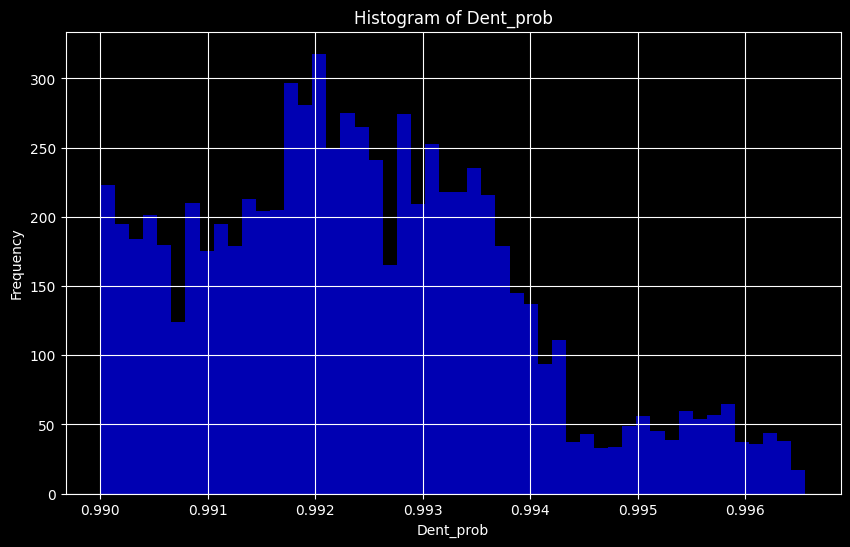

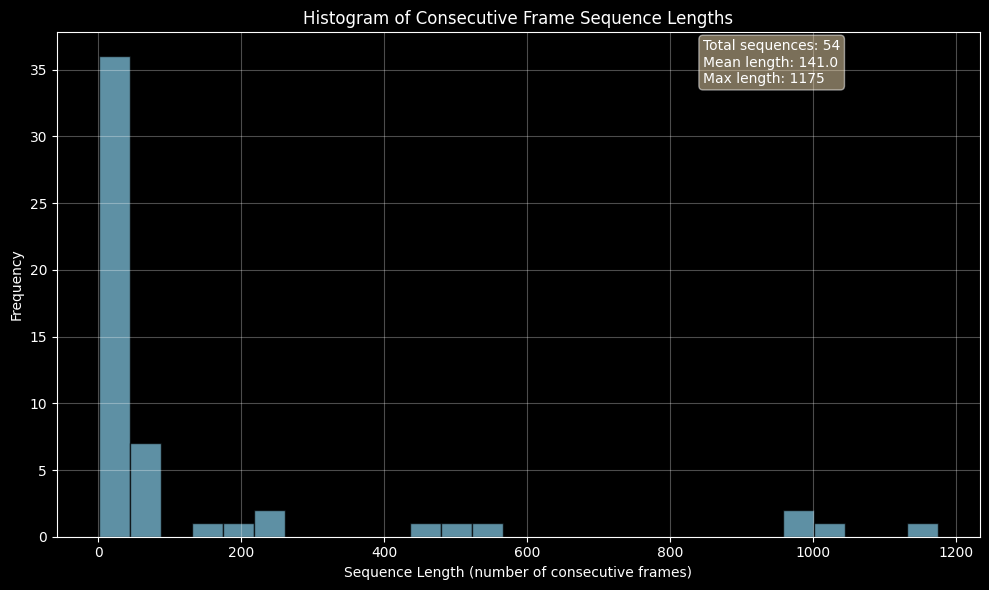

In [11]:
import numpy as np


def analyze_frame_sequences(df, frame_col='frame_idx', range_col='frame_range', plot=True):
    """
    Analyze consecutive frame sequences in a DataFrame.
    
    Args:
        df: DataFrame with frame indices
        frame_col: column name containing frame indices
        range_col: name for the new range column
        plot: whether to show histogram of sequence lengths
    
    Returns:
        tuple: (df_with_ranges, num_unique_sequences, sequence_lengths)
    """
    if len(df) == 0:
        print("Empty DataFrame")
        return df.copy(), 0, []
    
    # # Sort by frame index and reset index
    # df_sorted = df.copy().sort_values(frame_col).reset_index(drop=True) #aleardy sorted
    df_sorted = df.copy()
    
    
    # Find breaks in consecutive sequences
    frame_diff = df_sorted[frame_col].diff()
    breaks = (frame_diff != 1) & (frame_diff.notna())
    
    # Assign range IDs - each break starts a new range
    range_ids = breaks.cumsum()
    
    # Create range labels and calculate sequence lengths
    range_labels = []
    sequence_lengths = []
    
    for range_id in range_ids.unique():
        mask = range_ids == range_id
        start_frame = df_sorted.loc[mask, frame_col].min()
        end_frame = df_sorted.loc[mask, frame_col].max()
        sequence_length = end_frame - start_frame + 1
        
        range_labels.append(f"{start_frame}_{end_frame}")
        sequence_lengths.append(sequence_length)
    
    # Map range IDs to labels
    range_mapping = dict(zip(range_ids.unique(), range_labels))
    df_sorted[range_col] = range_ids.map(range_mapping)
    
    # Number of unique sequences
    num_unique_sequences = len(range_labels)
    
    # Print summary
    print(f"Total frames: {len(df_sorted)}")
    print(f"Number of unique sequences: {num_unique_sequences}")
    print(f"Sequence lengths - Min: {min(sequence_lengths)}, Max: {max(sequence_lengths)}, Mean: {np.mean(sequence_lengths):.1f}")
    
    # Plot histogram if requested
    if plot:
        plt.figure(figsize=(10, 6))
        plt.hist(sequence_lengths, bins=max(1, min(50, num_unique_sequences//2)), 
                 color='skyblue', alpha=0.7, edgecolor='black')
        plt.title('Histogram of Consecutive Frame Sequence Lengths')
        plt.xlabel('Sequence Length (number of consecutive frames)')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        
        # Add statistics text
        plt.text(0.7, 0.9, f'Total sequences: {num_unique_sequences}\n'
                           f'Mean length: {np.mean(sequence_lengths):.1f}\n'
                           f'Max length: {max(sequence_lengths)}', 
                 transform=plt.gca().transAxes, 
                 bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
    
    return df_sorted, num_unique_sequences, sequence_lengths


filtered_df_0_7 = create_df(track_idx=12, threshold=0.99)

# Create a histogram of lam_prob
plt.figure(figsize=(10, 6))
plt.hist(filtered_df_0_7['lam_prob'], bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Dent_prob')
plt.xlabel('Dent_prob')
plt.ylabel('Frequency')
plt.grid(True)  

count = len(filtered_df_0_7)
print(f"Threshold: {filtered_df_0_7}, Count: {count}")
df_with_ranges, num_sequences, seq_lengths = analyze_frame_sequences(filtered_df_0_7)



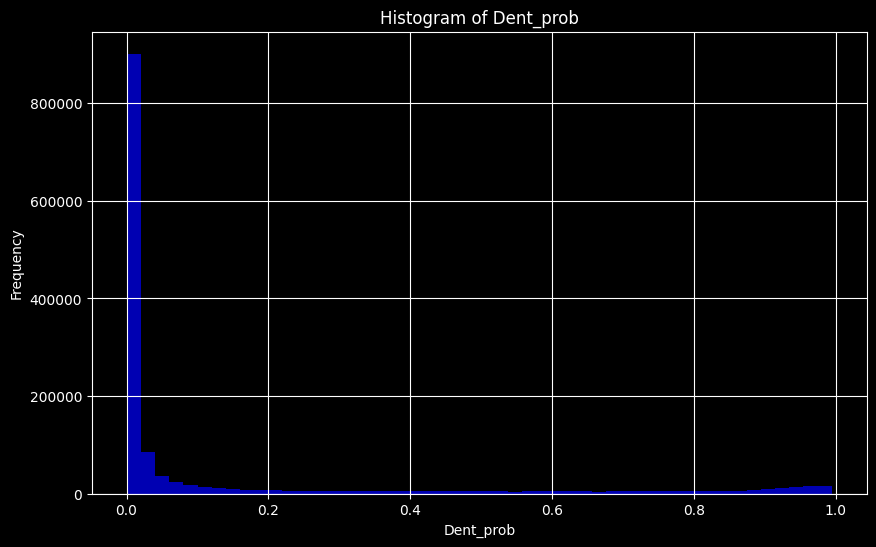

In [9]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
plt.hist(filtered_df_0_7['lam_prob'], bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Dent_prob')
plt.xlabel('Dent_prob')
plt.ylabel('Frequency')
plt.grid(True)  

In [8]:
display(df_with_ranges)
#13488222
#14469416

,inspection_id,clip_id,track_id,frame_idx,timer_tick,odometer_tick,lam_prob,frame_range
0,0A49KLT3B7Y,01-021-11YWDR6A,21,13150000,389242280,199691526,0.734983,13150000_14499999
1,0A49KLT3B7Y,01-021-11YWDR6A,21,13150001,389242304,199691541,0.734983,13150000_14499999
2,0A49KLT3B7Y,01-021-11YWDR6A,21,13150002,389242328,199691556,0.734983,13150000_14499999
3,0A49KLT3B7Y,01-021-11YWDR6A,21,13150003,389242351,199691571,0.734983,13150000_14499999
4,0A49KLT3B7Y,01-021-11YWDR6A,21,13150004,389242374,199691586,0.734983,13150000_14499999
...,...,...,...,...,...,...,...,...
49995,0A49KLT3B7Y,01-021-11YWDR6A,21,14499995,420933747,220192151,0.004165,13150000_14499999
49996,0A49KLT3B7Y,01-021-11YWDR6A,21,14499996,420933772,220192166,0.004165,13150000_14499999
49997,0A49KLT3B7Y,01-021-11YWDR6A,21,14499997,420933797,220192181,0.004165,13150000_14499999
49998,0A49KLT3B7Y,01-021-11YWDR6A,21,14499998,420933820,220192196,0.004165,13150000_14499999
